# [Synthesis] KAN-TabNet Interpretability & Visuals | Forest Cover

### Setup

In [1]:
import os
import sys
import json
import zipfile
import shutil
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline

In [2]:
if 'google.colab' in str(get_ipython()):
    from google.colab import userdata
    REPO_OWNER = "chuo-v"
    REPO_NAME = "kan-tabnet-experiments"

    if not os.path.exists(REPO_NAME):
        try:
            token = userdata.get('GITHUB_TOKEN')
            repo_url = f"https://{token}@github.com/{REPO_OWNER}/{REPO_NAME}.git"
            print("Cloning private repository via PAT...")
        except userdata.SecretNotFoundError:
            repo_url = f"https://github.com/{REPO_OWNER}/{REPO_NAME}.git"
            print("Cloning public repository...")

        !git clone {repo_url}

    os.chdir(f"/content/{REPO_NAME}/notebooks/forest_cover")
    sys.path.append("../../")

print(f"Working Directory Ready: {os.getcwd()}")

Cloning private repository via PAT...
Cloning into 'kan-tabnet-experiments'...
remote: Enumerating objects: 146, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 146 (delta 48), reused 61 (delta 37), pack-reused 64 (from 2)
Receiving objects: 100% (146/146), 21.81 MiB | 18.40 MiB/s, done.
Resolving deltas: 100% (51/51), done.
Working Directory Ready: /content/kan-tabnet-experiments/notebooks/forest_cover


In [3]:
# global plotting style
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

# directories
DATASET_NAME = 'forest_cover'
TABLES_DIR = f'../../results/{DATASET_NAME}/tables'
FIGURES_DIR = f'../../results/{DATASET_NAME}/figures'
MODELS_DIR = f'../../results/{DATASET_NAME}/models'
os.makedirs(FIGURES_DIR, exist_ok=True)

# load all metrics
files = {
    'Vanilla StepLR': '01_vanilla_baseline_step_lr_metrics.json',
    'KAN StepLR (Champion)': '02_kan_param_matched_step_lr_metrics.json',
    'Vanilla CosineLR': '03_vanilla_baseline_cosine_lr_metrics.json',
    'KAN CosineLR': '04_kan_param_matched_cosine_lr_metrics.json',
    'KAN Grid=3': '05_kan_sensitivity_grid_3_metrics.json',
    'KAN Grid=10': '06_kan_sensitivity_grid_10_metrics.json',
    'KAN 10x10': '07_kan_sensitivity_10x10_metrics.json'
}

metrics = {}
for name, filename in files.items():
    filepath = os.path.join(TABLES_DIR, filename)
    if os.path.exists(filepath):
        with open(filepath, 'r') as f:
            metrics[name] = json.load(f)

print(f"Successfully loaded {len(metrics)} experiment logs.")

Successfully loaded 7 experiment logs.


### Validation Accuracy (EMA Smoothed)

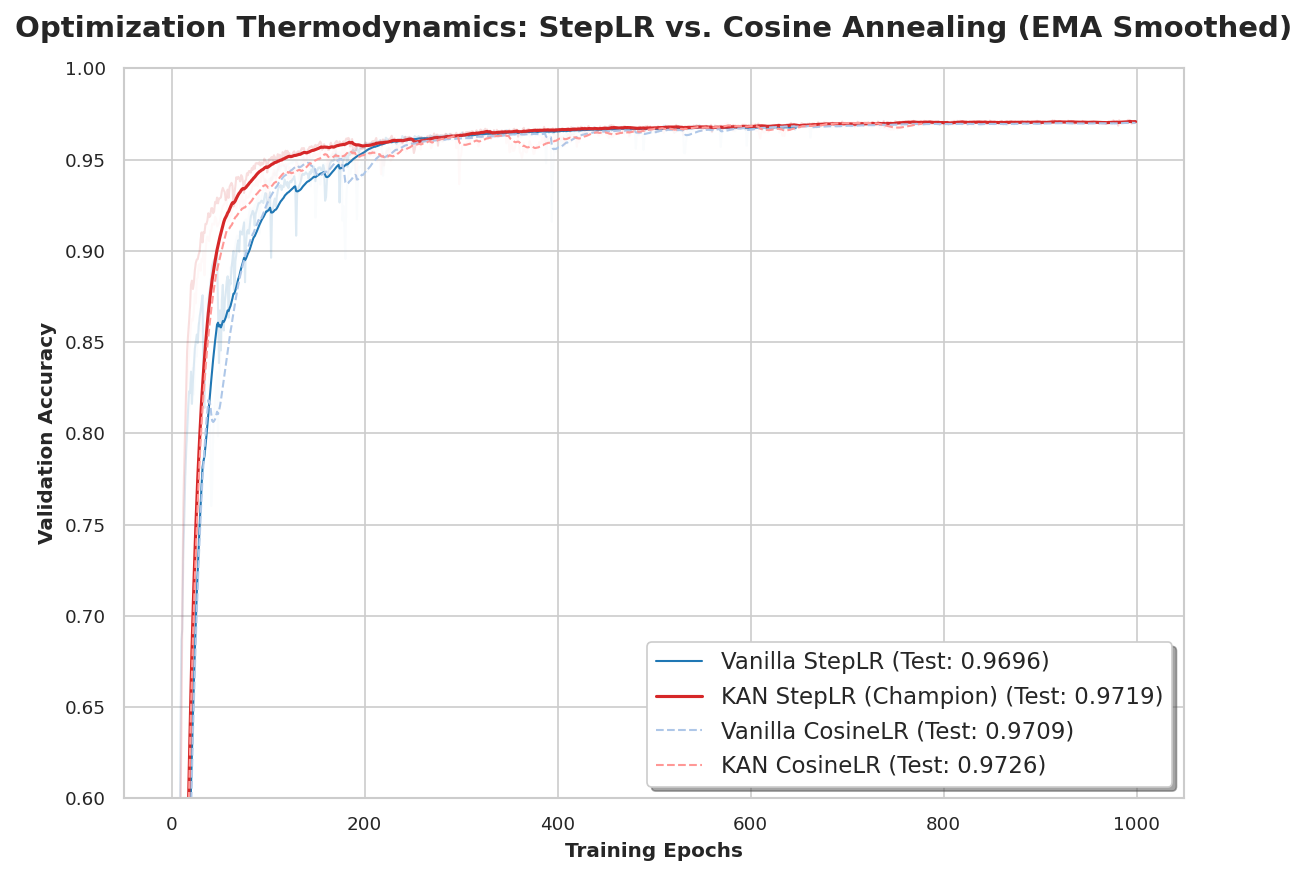

In [4]:
plt.figure(figsize=(8, 6))
ema_span = 20

colors = {'Vanilla StepLR': '#1f77b4', 'KAN StepLR (Champion)': '#d62728',
          'Vanilla CosineLR': '#aec7e8', 'KAN CosineLR': '#ff9896'}

for name in ['Vanilla StepLR', 'KAN StepLR (Champion)', 'Vanilla CosineLR', 'KAN CosineLR']:
    if name in metrics:
        history = metrics[name]['training_history']
        val_acc = history.get('valid_accuracy', history.get('val_0_accuracy', []))

        # Calculate EMA
        val_ema = pd.Series(val_acc).ewm(span=ema_span, adjust=False).mean()

        linestyle = '-' if 'StepLR' in name else '--'
        linewidth = 1.5 if 'Champion' in name else 1
        alpha_raw = 0.15 if 'StepLR' in name else 0.05

        # Plot raw (faint) and EMA (bold)
        plt.plot(val_acc, color=colors[name], linewidth=1, alpha=alpha_raw)
        plt.plot(val_ema, label=f"{name} (Test: {metrics[name]['final_test_accuracy']:.4f})",
                 color=colors[name], linewidth=linewidth, linestyle=linestyle)

plt.title('Optimization Thermodynamics: StepLR vs. Cosine Annealing (EMA Smoothed)', pad=15, fontweight='bold', fontsize=14)
plt.xlabel('Training Epochs', fontweight='bold')
plt.ylabel('Validation Accuracy', fontweight='bold')
plt.ylim(0.6, 1.0)
plt.legend(loc='lower right', frameon=True, shadow=True, fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/01_thermodynamics_ema.png', dpi=300)
plt.show()

### The Routing Bottleneck

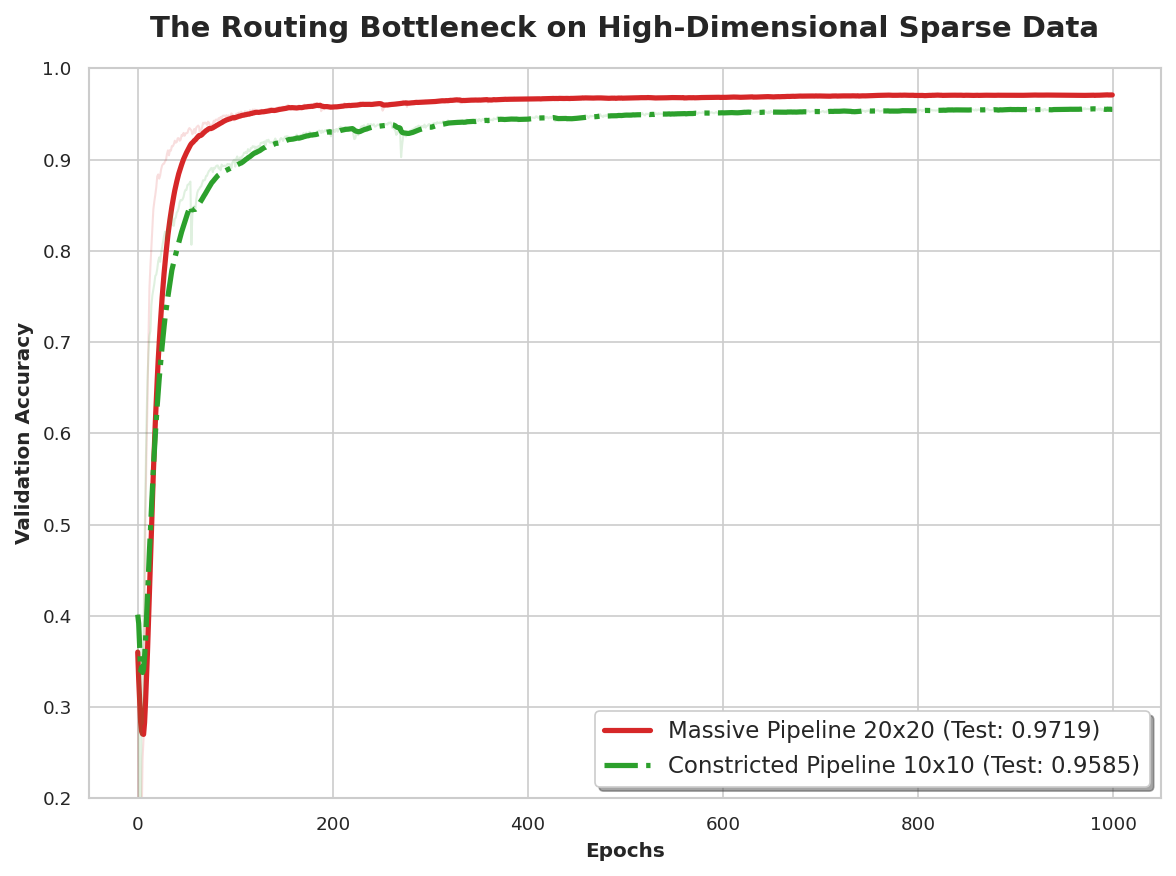

In [5]:
if 'KAN StepLR (Champion)' in metrics and 'KAN 10x10' in metrics:
    plt.figure(figsize=(8, 6))

    champ_acc = metrics['KAN StepLR (Champion)']['training_history'].get('valid_accuracy', [])
    bottle_acc = metrics['KAN 10x10']['training_history'].get('valid_accuracy', [])

    champ_ema = pd.Series(champ_acc).ewm(span=ema_span, adjust=False).mean()
    bottle_ema = pd.Series(bottle_acc).ewm(span=ema_span, adjust=False).mean()

    plt.plot(champ_acc, color='#d62728', linewidth=1, alpha=0.15)
    plt.plot(champ_ema, label=f"Massive Pipeline 20x20 (Test: {metrics['KAN StepLR (Champion)']['final_test_accuracy']:.4f})",
             color='#d62728', linewidth=2.5)

    plt.plot(bottle_acc, color='#2ca02c', linewidth=1, alpha=0.15)
    plt.plot(bottle_ema, label=f"Constricted Pipeline 10x10 (Test: {metrics['KAN 10x10']['final_test_accuracy']:.4f})",
             color='#2ca02c', linewidth=2.5, linestyle='-.')

    plt.title('The Routing Bottleneck on High-Dimensional Sparse Data', pad=15, fontweight='bold', fontsize=14)
    plt.xlabel('Epochs', fontweight='bold')
    plt.ylabel('Validation Accuracy', fontweight='bold')
    plt.ylim(0.2, 1.0)
    plt.legend(loc='lower right', frameon=True, shadow=True, fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/02_routing_bottleneck.png', dpi=300)
    plt.show()

### The Pareto Frontier (Parameters vs. Accuracy)

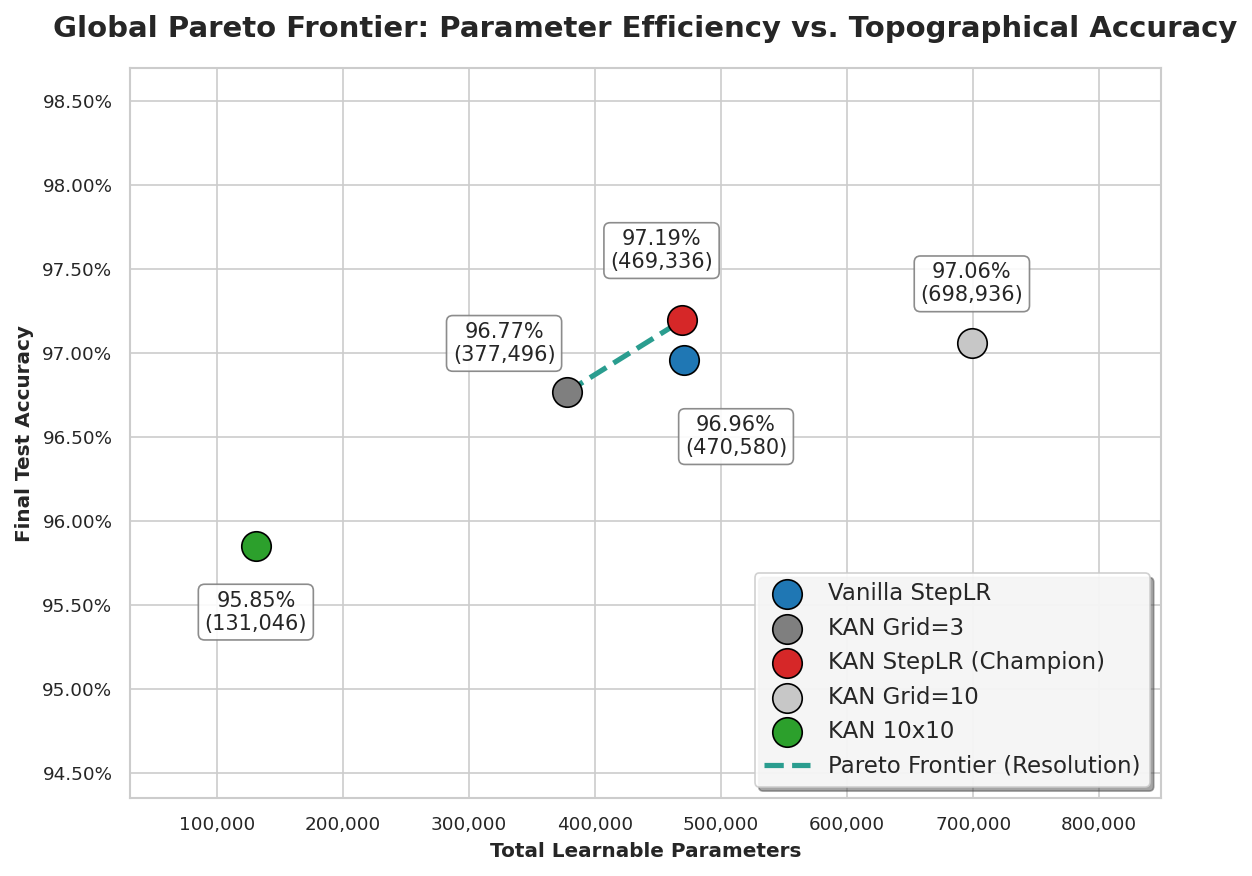

In [6]:
models_to_plot = ['Vanilla StepLR', 'KAN Grid=3', 'KAN StepLR (Champion)', 'KAN Grid=10', 'KAN 10x10']
colors = ['#1f77b4', '#7f7f7f', '#d62728', '#c7c7c7', '#2ca02c']

plt.figure(figsize=(8, 6))

plotted_params = []
plotted_accs = []

# specific (x, y) offsets for each model to prevent overlapping
custom_offsets = {
    'Vanilla StepLR': (25, -45),
    'KAN Grid=3': (-30, 15),
    'KAN StepLR (Champion)': (-10, 25),
    'KAN Grid=10': (0, 20),
    'KAN 10x10': (0, -40)
}

for idx, model in enumerate(models_to_plot):
    if model in metrics:
        param = metrics[model]['parameters']
        acc = metrics[model]['final_test_accuracy']
        plotted_params.append(param)
        plotted_accs.append(acc)

        plt.scatter(param, acc, label=model, color=colors[idx], s=200, edgecolor='black', zorder=5)

        offset = custom_offsets.get(model, (0, 15))

        plt.annotate(
            f'{acc*100:.2f}%\n({param:,})', (param, acc),
            textcoords="offset points", xytext=offset, ha='center',
            fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
            zorder=6 # ensure the text box draws on top of the scatter points and lines
        )

# draw the Pareto Frontier line connecting the grid experiments
frontier_models = ['KAN Grid=3', 'KAN StepLR (Champion)']
fx = [metrics[m]['parameters'] for m in frontier_models if m in metrics]
fy = [metrics[m]['final_test_accuracy'] for m in frontier_models if m in metrics]
if len(fx) == 2:
    plt.plot(fx, fy, color='#2a9d8f', linestyle='--', linewidth=2.5, label='Pareto Frontier (Resolution)', zorder=4)

plt.title('Global Pareto Frontier: Parameter Efficiency vs. Topographical Accuracy', pad=15, fontweight='bold', fontsize=14)
plt.xlabel('Total Learnable Parameters', fontweight='bold')
plt.ylabel('Final Test Accuracy', fontweight='bold')

# add some padding to the axes so the labels don't get cut off
plt.ylim(min(plotted_accs) - 0.015, max(plotted_accs) + 0.015)
plt.xlim(min(plotted_params) - 100000, max(plotted_params) + 150000)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y*100:.2f}%'))
plt.legend(loc='lower right', fontsize=11, framealpha=0.9, shadow=True)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/03_pareto_frontier.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretability - Extracting the B-Splines

Extracted B-Spline Tensor Shape: (80, 54, 8)
Output Neurons: 80 | Input Features: 54 | Control Points: 8



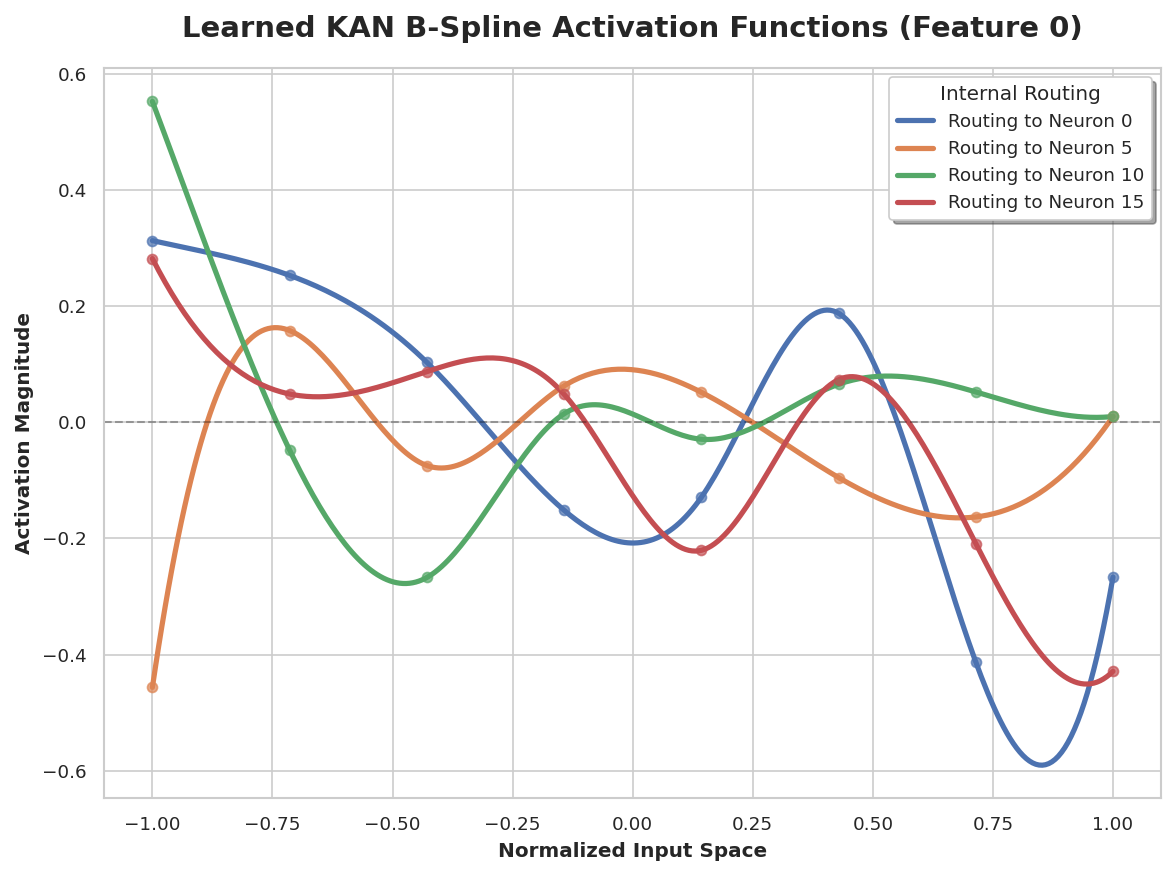

In [7]:
KAN_ZIP_PATH = f'{MODELS_DIR}/02_kan_param_matched_step_lr_469k.zip'
TEMP_EXTRACT_DIR = './tmp_kan_model'

if os.path.exists(KAN_ZIP_PATH):
    with zipfile.ZipFile(KAN_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(TEMP_EXTRACT_DIR)

    # load raw weights safely
    state_dict = torch.load(f'{TEMP_EXTRACT_DIR}/network.pt', map_location='cpu', weights_only=True)

    # target the first KAN Layer (input -> first hidden dimension)
    target_layer_name = 'tabnet.encoder.initial_splitter.shared.shared_layers.0.spline_weight'
    spline_weights = state_dict[target_layer_name].numpy()

    print(f"Extracted B-Spline Tensor Shape: {spline_weights.shape}")
    print(f"Output Neurons: {spline_weights.shape[0]} | Input Features: {spline_weights.shape[1]} | Control Points: {spline_weights.shape[2]}\n")

    # look at how input feature 0 is routed to 4 different internal neurons
    input_feature_idx = 0
    target_neurons = [0, 5, 10, 15]

    plt.figure(figsize=(8, 6))

    for neuron_idx in target_neurons:
        # extract the control points (G=5 + Spline Order=3 = 8 points)
        control_points = spline_weights[neuron_idx, input_feature_idx, :]
        x_grid = np.linspace(-1, 1, len(control_points))

        # cubic interpolation for visual smoothness
        spl = make_interp_spline(x_grid, control_points, k=3)
        x_smooth = np.linspace(x_grid.min(), x_grid.max(), 300)
        y_smooth = spl(x_smooth)

        plt.plot(x_smooth, y_smooth, linewidth=2.5, label=f'Routing to Neuron {neuron_idx}')
        plt.scatter(x_grid, control_points, zorder=5, alpha=0.7)

    plt.title(f'Learned KAN B-Spline Activation Functions (Feature {input_feature_idx})', pad=15, fontweight='bold', fontsize=14)
    plt.xlabel('Normalized Input Space', fontweight='bold')
    plt.ylabel('Activation Magnitude', fontweight='bold')
    plt.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.3)
    plt.legend(title="Internal Routing", frameon=True, shadow=True)

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/04_b_spline_control_polygons.png', dpi=300)
    plt.show()

    # cleanup
    shutil.rmtree(TEMP_EXTRACT_DIR)
else:
    print(f"Model zip not found at {KAN_ZIP_PATH}. Please ensure the model was saved correctly.")

### Global Feature Importance Allocation
During the initial training phase, the `compute_importance` flag was intentionally set to `False` to optimize training speed and minimize computational overhead. Because TabNet's feature importance is strictly data-dependent—calculated dynamically via instance-wise attention masks rather than static weights—the global importance arrays were not serialized with the model binaries.

To visualize the architectural routing efficiency, we must perfectly recreate the deterministic testing environment and pass `X_test` through the frozen models using the `.explain()` method.

##### **Part 1: Deterministic Environment Setup**
To ensure strict methodological parity, we must re-initialize the exact random seeds and computational determinism settings used during the training loops. This guarantees the PyTorch backend processes the data topology exactly as it did during the initial evaluations.

In [8]:
%%capture
# install TabNet fork which allows switching between vanilla TabNet and KAN-TabNet
!pip install git+https://github.com/chuo-v/tabnet.git@v1.0.1-kan

In [9]:
import random

seed = 11
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [10]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

##### **Part 2: Topographical Data Preparation**
With the deterministic environment locked, we fetch and split the dataset to isolate the exact `X_test` tensor that the models were evaluated against.

In [11]:
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from pytorch_tabnet.tab_model import TabNetClassifier

dataset = fetch_covtype()

X = dataset.data
# CovType is 1-indexed (1 to 7); PyTorch expects 0-indexed labels
y = dataset.target - 1

# divide dataset into 80% train, 20% temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=seed, stratify=y
)

# divide temp into 10% validation and 10% test
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=seed, stratify=y_temp
)

##### **Part 3: Attention Extraction and Visualization**
We load the pre-trained, parameter-matched models and push `X_test` through an inference pass using the `.explain()` method. By averaging the resulting data-dependent instance masks, we successfully map the global feature importance allocation.

Loading models and extracting attention masks...
Calculating attention dynamics...
Plotting heatmap...


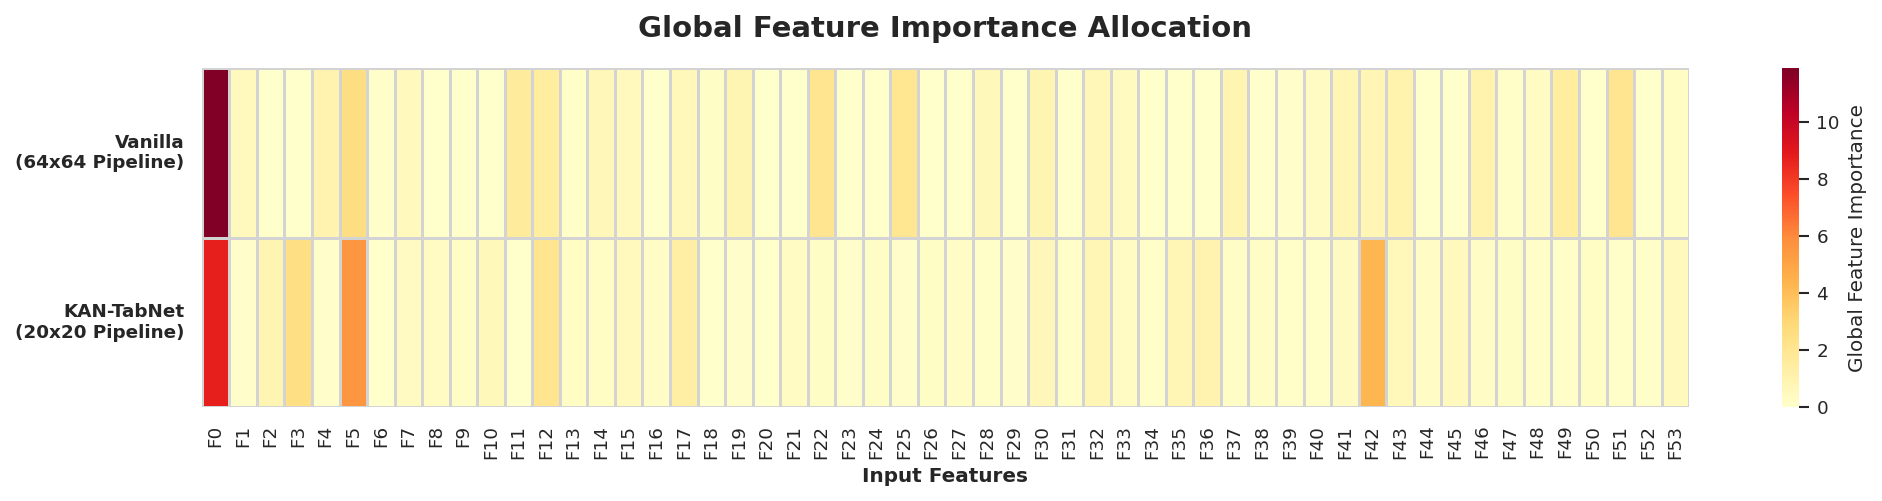

In [12]:
print("Loading models and extracting attention masks...")

# initialize classifiers and load saved models
clf_vanilla = TabNetClassifier()
clf_kan = TabNetClassifier()
clf_vanilla.load_model(f'{MODELS_DIR}/03_vanilla_baseline_cosine_lr_470k.zip')
clf_kan.load_model(f'{MODELS_DIR}/04_kan_param_matched_cosine_lr_469k.zip')

# extract interpretability masks
print("Calculating attention dynamics...")
explain_matrix_vanilla, _ = clf_vanilla.explain(X_test)
explain_matrix_kan, _ = clf_kan.explain(X_test)

vanilla_imp = explain_matrix_vanilla.mean(axis=0)
kan_imp = explain_matrix_kan.mean(axis=0)

# generate visualization
print("Plotting heatmap...")
importance_matrix = np.vstack([vanilla_imp, kan_imp])

plt.figure(figsize=(14, 3.5))
ax = sns.heatmap(
    importance_matrix,
    cmap="YlOrRd",
    cbar_kws={'label': 'Global Feature Importance'},
    yticklabels=['Vanilla\n(64x64 Pipeline)', 'KAN-TabNet\n(20x20 Pipeline)'],
    xticklabels=[f"F{i}" for i in range(54)],
    linewidths=0.5,
    linecolor='lightgray'
)

plt.title('Global Feature Importance Allocation', pad=15, fontweight='bold', fontsize=14)
plt.xlabel('Input Features', fontweight='bold')
plt.yticks(rotation=0, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/05_feature_importance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()